# Set Up

In [1]:
#!pip install scikit-learn pandas numpy matplotlib seaborn joblib shap xgboost

In [2]:
# Force-downgrade NumPy to a stable 1.x version to prevent impor errors
#!pip install "numpy<2" --force-reinstall

In [3]:
# pip install keras-tuner

In [4]:
# pip install geodatasets

In [5]:
import os
import pandas as pd
import numpy as np
import geopandas as gpd
#import geodatasets
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import shap

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
import keras_tuner as kt
from sklearn.inspection import permutation_importance
from tensorflow.keras.models import load_model

ModuleNotFoundError: No module named 'keras_tuner'

In [3]:
# 1. Mount the drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Define the NEW path (This is the standard Colab Linux path)
# Note: 'My Drive' usually has a space in it on Google's servers.
path = '/content/drive/MyDrive/Full Corn Yield Prediction'

# 3. Change directory
if os.path.exists(path):
    os.chdir(path)
    print("Success! You are now working in your Google Drive folder.")
    print(f"Current Files: {os.listdir()[:5]}") # Prints first 5 files to verify
else:
    print("Path not found. Open the file folder icon on the left to check the folder name.")

Mounted at /content/drive
Success! You are now working in your Google Drive folder.
Current Files: ['anom_model_results.csv', 'raw_model_results.csv', 'tuning_dir_anom', 'tuning_dir_raw', 'models_anom']


# Data

In [7]:
# Path to your saved joblib file
DATA_PATH = r'Processed Data/mlData.joblib'

# Load the entire multi-stage dictionary
try:
    stage_datasets = joblib.load(DATA_PATH)
    print("Data loaded successfully.")
    print(f"Stages available: {list(stage_datasets.keys())}")
except FileNotFoundError:
    print("Error: Could not find the file.")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.4.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Data loaded successfully.
Stages available: ['V6', 'V12', 'R1', 'R3']


In [8]:
# static_features = [
#    'year_index', 'lat', 'lon', 'yield_prev_year', 'yield_prev_five', 
#    'acres_planted_curr', 'acres_planted_raw_anom', 'acres_planted_pct_anom', 
#    'abandonment_rate_prev_five', 'gdd_full_season_hist', 'precip_full_season_hist',
#    'precip_oct_april_curr', 'precip_oct_april_anom', 'extreme_cold_nov_mar',
#    'slope', 'sand_pct', 'silt_pct', 'clay_pct', 'organic_matter_pct', 
#    'pH_soil', 'awc_soil', 'cec_soil'
# ]

# Common Functions

In [8]:
class YieldEvaluator:
    def __init__(self, target_idx):
        """
        target_idx: 0 for 'corn_yield'
        target_idx: 1 for 'corn_yield_anom'
        """
        self.target_idx = target_idx
        self.all_results = {} # Comprehensive dictionary to store everything

    def unscale_predictions(self, y_pred_scaled, scaler_y):
        """Universal helper to turn scaled outputs back into bushels/acre."""
        # Create a dummy array for the 2-column scaler (yield, yield_anom)
        dummy = np.zeros((len(y_pred_scaled), 2))
        dummy[:, self.target_idx] = y_pred_scaled.flatten()
        return scaler_y.inverse_transform(dummy)[:, self.target_idx]

    def evaluate(self, y_true_raw, y_pred_raw, model_name, stage):
        """Prints and stores results in real-world units (bu/ac)."""
        mae = mean_absolute_error(y_true_raw, y_pred_raw)
        rmse = np.sqrt(mean_squared_error(y_true_raw, y_pred_raw))
        r2 = r2_score(y_true_raw, y_pred_raw)
        
        # Store in the master dictionary
        if stage not in self.all_results:
            self.all_results[stage] = {}
        self.all_results[stage][model_name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
        
        print(f"[{stage} | {model_name}] MAE: {mae:.2f} bu/ac | RMSE: {rmse:.2f} bu/ac | R2: {r2:.4f}")
        return self.all_results[stage][model_name]

    def plot_loss(self, history, model_name, stage):
        """Universal plot for future Neural Network training curves."""
        plt.figure(figsize=(8, 4))
        plt.plot(history.history['loss'], label='Train')
        plt.plot(history.history['val_loss'], label='Val')
        plt.title(f"Loss Curve: {model_name} ({stage})")
        plt.legend()
        plt.show()

    def plot_baseline_importance(self, model, feature_names, model_name, stage, top_n=10):
        """Universal feature importance for Linear, RF, and XGBoost."""
        plt.figure(figsize=(10, 5))
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
        elif hasattr(model, 'coef_'):
            importances = np.abs(model.coef_.flatten()) # Use absolute value for impact
        else: return

        feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        feat_imp.head(top_n).plot(kind='barh', color='skyblue')
        plt.title(f"Top Features: {model_name} ({stage})")
        plt.gca().invert_yaxis()
        plt.show()

    def plot_nn_importance(self, model, X_val, y_val, feature_names, stage, top_n=15):
        """Calculates Permutation Importance for Neural Networks."""
        print(f"Calculating feature importance for {stage} (this may take a minute)...")
        
        # Helper to make the Keras model look like a Scikit-Learn model
        def score_func(X, y):
            yp = model.predict(X, verbose=0)
            return -mean_squared_error(y, yp) # Use negative MSE as 'score'

        # We manually calculate permutation importance
        baseline_score = score_func(X_val, y_val)
        importances = []
        
        for i in range(X_val.shape[1]):
            save_col = X_val[:, i].copy()
            np.random.shuffle(X_val[:, i]) # Scramble the feature
            shuffled_score = score_func(X_val, y_val)
            importances.append(baseline_score - shuffled_score)
            X_val[:, i] = save_col # Restore the feature
        
        importance_df = pd.Series(importances, index=feature_names).sort_values(ascending=False)
        
        plt.figure(figsize=(10, 6))
        importance_df.head(top_n).plot(kind='barh', color='teal')
        plt.title(f"Neural Network Feature Importance: {stage}")
        plt.gca().invert_yaxis()
        plt.show()

    def print_results_summary(self):    
        # Flatten the nested dictionary
        rows = []
        for stage, models in self.all_results.items():
            for model_name, metrics in models.items():
                row = {'Stage': stage, 'Model': model_name}
                row.update(metrics)
                rows.append(row)
        
        df = pd.DataFrame(rows)
        
        # Reorder columns for readability
        cols = ['Stage', 'Model', 'MAE', 'RMSE', 'R2']
        df = df[cols].sort_values(by=['Stage', 'R2'], ascending=[True, False])
        
        print("\n" + "="*50)
        print("      CORN YIELD ANOMALY PERFORMANCE SUMMARY")
        print("="*50)
        display(df.style.background_gradient(subset=['R2'], cmap='RdYlGn'))
        return df

In [10]:
# Initialize the tool
anomEvaluator = YieldEvaluator(target_idx=1) # Predicting corn_yield_anom

In [11]:
def save_results_to_csv(evaluator, filename="model_results.csv"):
    rows = []
    # Flatten the nested dictionary: {Stage: {Model: {Metric: Value}}}
    for stage, models in evaluator.all_results.items():
        for model_name, metrics in models.items():
            row = {'Stage': stage, 'Model': model_name}
            row.update(metrics) # Adds MAE, RMSE, R2
            rows.append(row)
    
    df = pd.DataFrame(rows)
    
    # Save to CSV (appends if file exists, or creates new)
    if not os.path.isfile(filename):
        df.to_csv(filename, index=False)
        print(f"✅ Results successfully saved to {filename}")
        return df
    else:
        # Load existing, combine, and drop duplicates to avoid double-entry
        existing_df = pd.read_csv(filename)
        combined_df = pd.concat([existing_df, df]).drop_duplicates(subset=['Stage', 'Model'], keep='last')
        combined_df.to_csv(filename, index=False)
        print(f"✅ Results successfully saved to {filename}")
        return combined_df

## Universal Neural Network Functions

### Function for creating initial neural network

In [12]:
# build neural net function
def build_initial_nn(input_shape):
    """
    Creates the baseline Neural Network architecture.
    Identical for all stages to ensure a fair starting point.
    """
    model = keras.Sequential([
        # Input Layer
        layers.Input(shape=(input_shape,)),
        
        # Hidden Layer 1
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.2), # Prevents overfitting on noisy weather data
        
        # Hidden Layer 2
        layers.Dense(32, activation='relu'),
        
        # Output Layer (Linear for regression)
        layers.Dense(1) 
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model


# tune neural net hyperparamters function
def build_tunable_nn(hp, input_shape):
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_shape,)))
    
    # Tune the number of layers and units
    for i in range(hp.Int('num_layers', 1, 3)):
        model.add(layers.Dense(
            units=hp.Int(f'units_{i}', min_value=32, max_value=128, step=32),
            activation='relu'
        ))
        model.add(layers.Dropout(hp.Float(f'dropout_{i}', 0.0, 0.4, step=0.1)))
    
    model.add(layers.Dense(1))
    
    # Tune the learning rate
    lr = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=lr), loss='mse')
    return model

In [13]:
# Early stopping prevents the model from over-training 
early_stop = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

### Engineering/pruning functions

In [14]:
def add_bio_features(X, names, current_stage, prev_stage=None):
    """Adds biological indicators to the feature set."""
    df = pd.DataFrame(X, columns=names)
    # Atmospheric Thirst
    df[f'{current_stage}_thirst'] = df[f'{current_stage}_vpd_mean'] / (df[f'{current_stage}_precip_curr'] + 0.01)
    # Cumulative Heat/Dryness Stress
    df[f'{current_stage}_stress_idx'] = df[f'{current_stage}_sdd_curr'] * df[f'{current_stage}_vpd_mean']
    # Growth Velocity
    if prev_stage:
        df[f'{current_stage}_velocity'] = df[f'{current_stage}_evi_curr'] - df[f'{prev_stage}_evi_curr']
    else:
        df[f'{current_stage}_velocity'] = df[f'{current_stage}_evi_curr'] - df[f'{current_stage}_evi_anom']
    return df.values, df.columns.tolist()

def get_pruned_indices(model, X_val, y_val, feature_names, top_n=15):
    """Uses the tuned model to identify the best features via permutation."""
    def score_func(X, y):
        yp = model.predict(X, verbose=0)
        return -mean_squared_error(y, yp)
    
    baseline = score_func(X_val, y_val)
    importances = []
    for i in range(X_val.shape[1]):
        save = X_val[:, i].copy()
        np.random.shuffle(X_val[:, i])
        importances.append(baseline - score_func(X_val, y_val))
        X_val[:, i] = save
    return np.argsort(importances)[::-1][:top_n]

### Ensemble neural networks

In [15]:
def get_ensemble_predictions(nn_model, xgb_model, X_test_nn, X_test_xgb, scaler_y, evaluator, weight_nn=0.5):
    """
    Calculates weighted average of NN and XGBoost.
    Returns the unscaled (real-world) predictions.
    """
    # Get NN predictions and unscale
    nn_scaled = nn_model.predict(X_test_nn, verbose=0)
    nn_raw = evaluator.unscale_predictions(nn_scaled, scaler_y)
    
    # Get XGBoost predictions and unscale
    xgb_scaled = xgb_model.predict(X_test_xgb)
    xgb_raw = evaluator.unscale_predictions(xgb_scaled, scaler_y)
    
    # Weighted Average
    weight_xgb = 1.0 - weight_nn
    return (weight_nn * nn_raw) + (weight_xgb * xgb_raw)

# Baselines - Yield Anom


==================== PROCESSING STAGE: V6 ====================
[V6 | Prev Year Yield] MAE: 157.61 bu/ac | RMSE: 164.23 bu/ac | R2: -48.2772
[V6 | 5-Year Avg Yield] MAE: 156.23 bu/ac | RMSE: 161.33 bu/ac | R2: -46.5575
[V6 | Linear Regression] MAE: 18.31 bu/ac | RMSE: 25.28 bu/ac | R2: -0.1681
[V6 | Random Forest] MAE: 17.87 bu/ac | RMSE: 23.09 bu/ac | R2: 0.0260


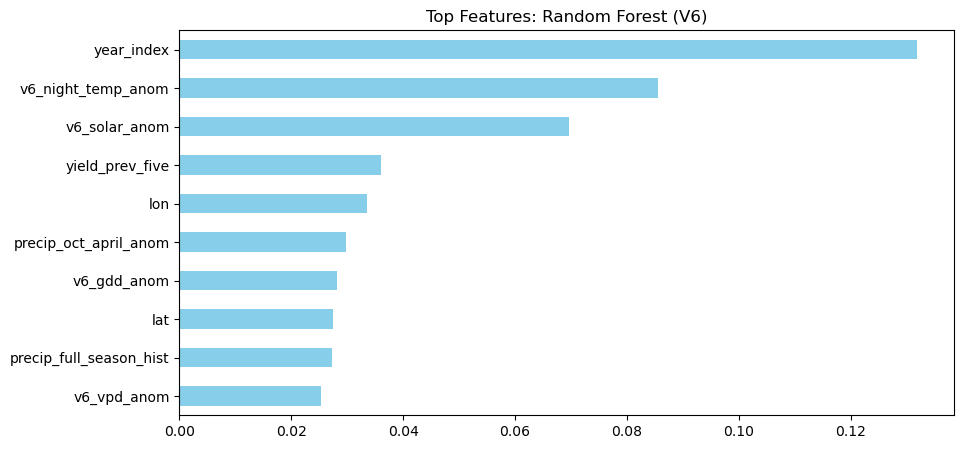

[V6 | XGBoost] MAE: 17.54 bu/ac | RMSE: 22.97 bu/ac | R2: 0.0362

==================== PROCESSING STAGE: V12 ====================
[V12 | Prev Year Yield] MAE: 157.61 bu/ac | RMSE: 164.23 bu/ac | R2: -48.2772
[V12 | 5-Year Avg Yield] MAE: 156.23 bu/ac | RMSE: 161.33 bu/ac | R2: -46.5575
[V12 | Linear Regression] MAE: 18.44 bu/ac | RMSE: 24.55 bu/ac | R2: -0.1015
[V12 | Random Forest] MAE: 20.54 bu/ac | RMSE: 27.09 bu/ac | R2: -0.3409


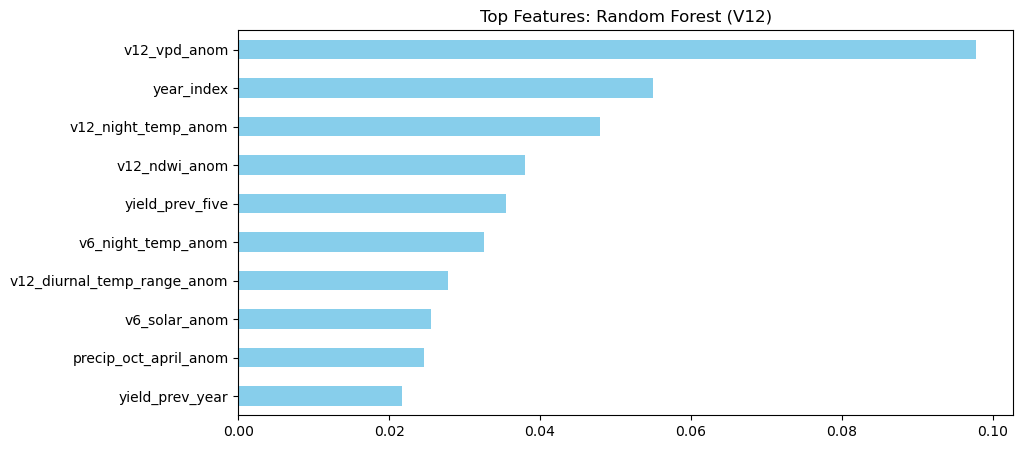

[V12 | XGBoost] MAE: 17.63 bu/ac | RMSE: 22.81 bu/ac | R2: 0.0495

==================== PROCESSING STAGE: R1 ====================
[R1 | Prev Year Yield] MAE: 157.61 bu/ac | RMSE: 164.23 bu/ac | R2: -48.2772
[R1 | 5-Year Avg Yield] MAE: 156.23 bu/ac | RMSE: 161.33 bu/ac | R2: -46.5575
[R1 | Linear Regression] MAE: 16.33 bu/ac | RMSE: 21.13 bu/ac | R2: 0.1844
[R1 | Random Forest] MAE: 15.03 bu/ac | RMSE: 19.40 bu/ac | R2: 0.3120


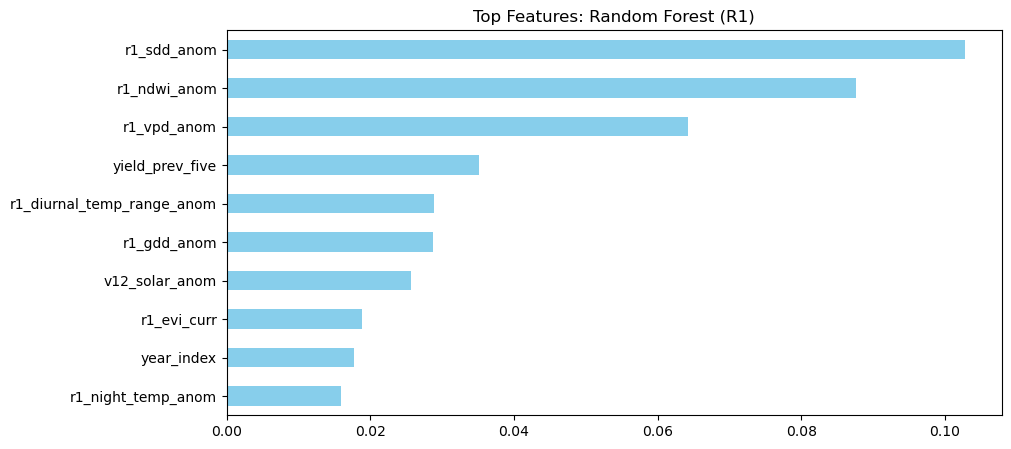

[R1 | XGBoost] MAE: 14.87 bu/ac | RMSE: 19.06 bu/ac | R2: 0.3361

==================== PROCESSING STAGE: R3 ====================
[R3 | Prev Year Yield] MAE: 157.61 bu/ac | RMSE: 164.23 bu/ac | R2: -48.2772
[R3 | 5-Year Avg Yield] MAE: 156.23 bu/ac | RMSE: 161.33 bu/ac | R2: -46.5575
[R3 | Linear Regression] MAE: 15.66 bu/ac | RMSE: 21.04 bu/ac | R2: 0.1909
[R3 | Random Forest] MAE: 14.62 bu/ac | RMSE: 19.66 bu/ac | R2: 0.2936


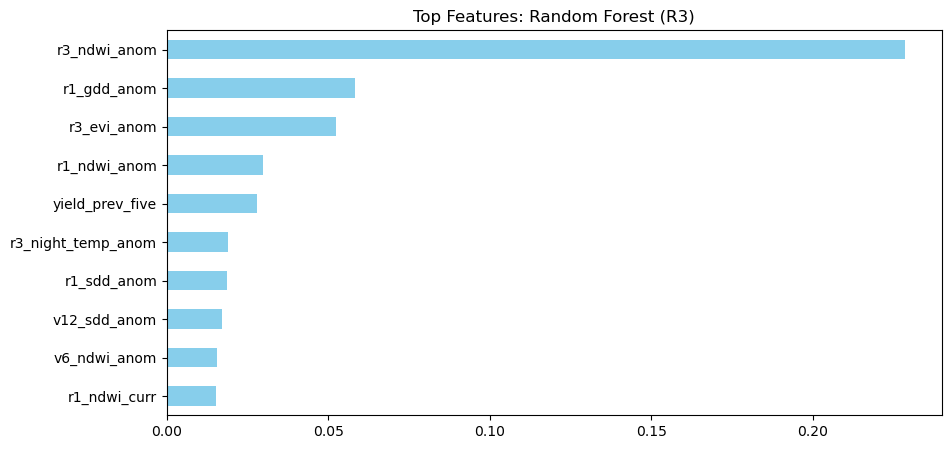

[R3 | XGBoost] MAE: 14.36 bu/ac | RMSE: 19.17 bu/ac | R2: 0.3288

✅ All Baseline Experiments Complete.


In [16]:
# Map proxy column indices based on your static_features list
# yield_prev_year = index 3, yield_prev_five = index 4
proxy_cols = {
    'Prev Year Yield': 3,
    '5-Year Avg Yield': 4
}

for stage in ['V6', 'V12', 'R1', 'R3']:
    print(f"\n{'='*20} PROCESSING STAGE: {stage} {'='*20}")
    
    # Extract data for this stage
    data = stage_datasets[stage]
    current_feature_names = data['feature_names'] 
    
    X_train, y_train = data['X_train'], data['y_train'][:, anomEvaluator.target_idx]
    X_test = data['X_test']
    y_test_raw = data['y_test_raw'][:, anomEvaluator.target_idx]

    
    # --- 1 & 2: PROXY BASELINES ---
    # We unscale X_test to get the original values of the 'proxy' columns
    X_test_raw = data['scaler_x'].inverse_transform(X_test)
    
    for name, col_idx in proxy_cols.items():
        y_pred_proxy = X_test_raw[:, col_idx]
        anomEvaluator.evaluate(y_test_raw, y_pred_proxy, name, stage)

    # --- 3: LINEAR REGRESSION ---
    lr = LinearRegression().fit(X_train, y_train)
    y_pred_scaled = lr.predict(X_test)
    y_pred_raw = anomEvaluator.unscale_predictions(y_pred_scaled, data['scaler_y'])
    anomEvaluator.evaluate(y_test_raw, y_pred_raw, "Linear Regression", stage)

    # --- 4: RANDOM FOREST ---
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X_train, y_train)
    y_pred_scaled = rf.predict(X_test)
    y_pred_raw = anomEvaluator.unscale_predictions(y_pred_scaled, data['scaler_y'])
    anomEvaluator.evaluate(y_test_raw, y_pred_raw, "Random Forest", stage)
    anomEvaluator.plot_baseline_importance(rf, current_feature_names, "Random Forest", stage)

    # --- 5: XGBOOST ---
    xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42).fit(X_train, y_train)
    y_pred_scaled = xgb.predict(X_test)
    y_pred_raw = anomEvaluator.unscale_predictions(y_pred_scaled, data['scaler_y'])
    anomEvaluator.evaluate(y_test_raw, y_pred_raw, "XGBoost", stage)

print("\n✅ All Baseline Experiments Complete.")

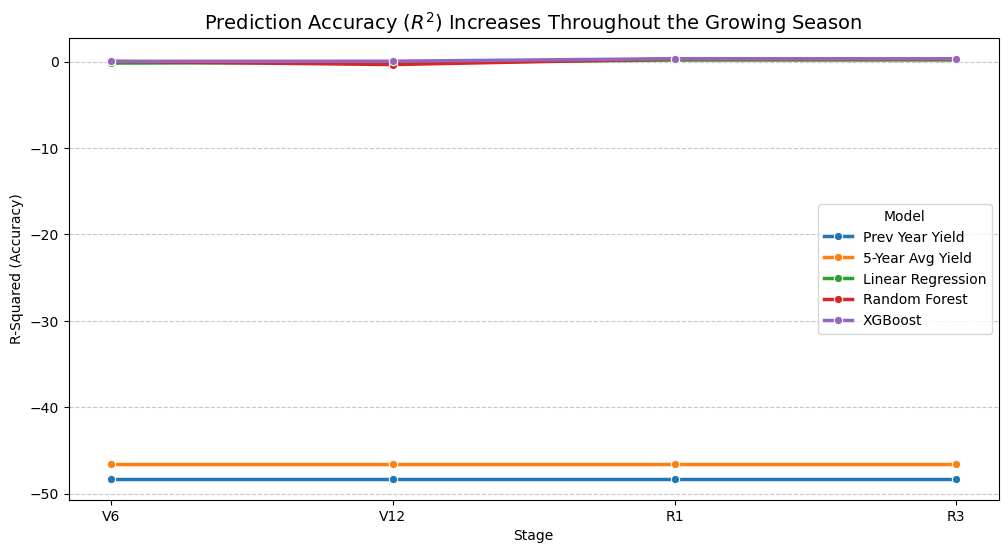


FINAL BASELINE METRIC SUMMARY (MAE in bu/ac):


Stage,R1,R3,V12,V6
Model,,,,
5-Year Avg Yield,156.232146,156.232146,156.232146,156.232146
Linear Regression,16.329141,15.661188,18.442280,18.305678
Prev Year Yield,157.607570,157.607570,157.607570,157.607570
Random Forest,15.031561,14.616625,20.539584,17.872842
XGBoost,14.867232,14.362557,17.627497,17.544091


In [17]:
# Flatten the dictionary for plotting
results_list = []
for stage, models in anomEvaluator.all_results.items():
    for model_name, metrics in models.items():
        results_list.append({'Stage': stage, 'Model': model_name, 'MAE': metrics['MAE'], 'R2': metrics['R2']})

results_df = pd.DataFrame(results_list)

# Plot R-Squared across time
plt.figure(figsize=(12, 6))
sns.lineplot(data=results_df, x='Stage', y='R2', hue='Model', marker='o', linewidth=2.5)
plt.title("Prediction Accuracy ($R^2$) Increases Throughout the Growing Season", fontsize=14)
plt.ylabel("R-Squared (Accuracy)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Display the final summary table
print("\nFINAL BASELINE METRIC SUMMARY (MAE in bu/ac):")
display(results_df.pivot(index='Model', columns='Stage', values='MAE'))

# Neural Networks - Yield Anom

## V6

In [18]:
stage = 'V6'
data = stage_datasets[stage]

# Prepare Data
X_train_v6, y_train_v6 = data['X_train'], data['y_train'][:, anomEvaluator.target_idx]
X_val_v6, y_val_v6 = data['X_val'], data['y_val'][:, anomEvaluator.target_idx]
X_test_v6 = data['X_test']
y_test_raw_v6 = data['y_test_raw'][:, anomEvaluator.target_idx]
feat_names_v6 = data['feature_names']

### Initial

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[V6 | Initial Neural Network] MAE: 17.52 bu/ac | RMSE: 23.54 bu/ac | R2: -0.0123


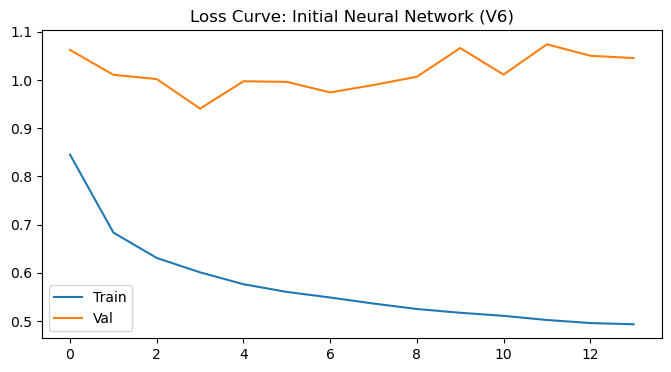

In [19]:
# Build and train initial neural network
model_v6_init = build_initial_nn(X_train_v6.shape[1])
history_v6_init = model_v6_init.fit(
    X_train_v6, y_train_v6,
    validation_data=(X_val_v6, y_val_v6),
    epochs=50, batch_size=32, callbacks=[early_stop], verbose=0
)

# Evaluate initial nn using anomEvaluator
y_pred_scaled_v6 = model_v6_init.predict(X_test_v6)
y_pred_raw_v6 = anomEvaluator.unscale_predictions(y_pred_scaled_v6, data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v6, y_pred_raw_v6, "Initial Neural Network", stage)
anomEvaluator.plot_loss(history_v6_init, "Initial Neural Network", stage)

Starting Hyperparameter Search for V6...

47/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[V6 | Tuned NN] MAE: 17.20 bu/ac | RMSE: 23.85 bu/ac | R2: -0.0396
Calculating feature importance for V6 (this may take a minute)...


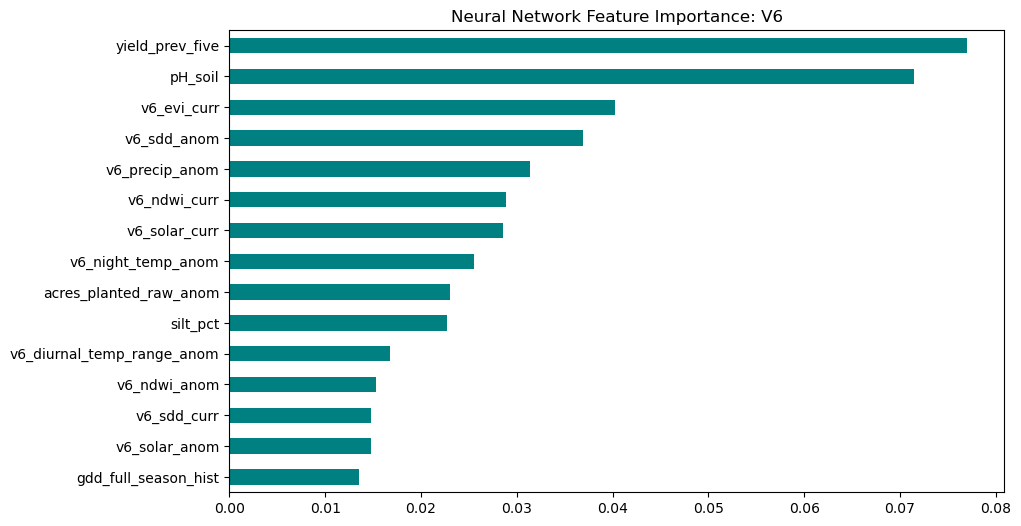

In [20]:
# initial model hyperparameter tuning
tuner_v6 = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v6.shape[1]),
    objective='val_loss', max_trials=10, executions_per_trial=1, directory='tuning_dir_anom', project_name=f'{stage}_initial'
)

print(f"Starting Hyperparameter Search for {stage}...")
tuner_v6.search(X_train_v6, y_train_v6, epochs=50, validation_data=(X_val_v6, y_val_v6), callbacks=[early_stop], verbose=0)

# get best model and evaluate
model_v6_tuned = tuner_v6.get_best_models(num_models=1)[0]
y_pred_tuned_raw_v6 = anomEvaluator.unscale_predictions(model_v6_tuned.predict(X_test_v6), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v6, y_pred_tuned_raw_v6, "Tuned NN", stage)

# feature analysis
anomEvaluator.plot_nn_importance(model_v6_tuned, X_val_v6, y_val_v6, feat_names_v6, stage)

### Engineering/Pruning

In [21]:
# feature engineering + train new neural network

# new data sets (e = engineered)
X_train_v6_e, feat_names_v6_e = add_bio_features(X_train_v6, data['feature_names'], 'v6')
X_val_v6_e, _ = add_bio_features(X_val_v6, data['feature_names'], 'v6')
X_test_v6_e, _ = add_bio_features(X_test_v6, data['feature_names'], 'v6')

# train new model on data sets with engineered features + find best hyperparameters
tuner_v6_eng = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v6_e.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_engineered'
)
print(f"Tuning Engineered Model for {stage}...")
tuner_v6_eng.search(X_train_v6_e, y_train_v6, epochs=50, validation_data=(X_val_v6_e, y_val_v6), callbacks=[early_stop], verbose=0)
model_v6_eng_tuned = tuner_v6_eng.get_best_models(num_models=1)[0]

# Evaluate Engineered
y_pred_v6_eng = anomEvaluator.unscale_predictions(model_v6_eng_tuned.predict(X_test_v6_e), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v6, y_pred_v6_eng, "Tuned Engineered NN", stage)

Tuning Engineered Model for V6...


C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[V6 | Tuned Engineered NN] MAE: 16.84 bu/ac | RMSE: 23.37 bu/ac | R2: 0.0019


{'MAE': 16.838311499626514,
 'RMSE': 23.372454493970825,
 'R2': 0.0019017155437439648}

In [22]:
# prune features to get rid of useless ones and decrease noise

# find top 30 most useful features and only save them (p = pruned dataset)
top_idx_v6 = get_pruned_indices(model_v6_eng_tuned, X_val_v6_e, y_val_v6, feat_names_v6_e, top_n=30)
X_train_v6_p, X_val_v6_p, X_test_v6_p = X_train_v6_e[:, top_idx_v6], X_val_v6_e[:, top_idx_v6], X_test_v6_e[:, top_idx_v6]
feat_names_v6_p = [feat_names_v6_e[i] for i in top_idx_v6]
print(f"Top 30 Features for {stage}: {feat_names_v6_p}")

# train another model on pruned data set + find best hyperparameters
tuner_v6_pruned = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v6_p.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_pruned'
)
print(f"Final Tuning for Pruned {stage} Model...")
tuner_v6_pruned.search(X_train_v6_p, y_train_v6, epochs=50, validation_data=(X_val_v6_p, y_val_v6), callbacks=[early_stop], verbose=0)
model_v6_pruned_tuned = tuner_v6_pruned.get_best_models(num_models=1)[0]

# Final Evaluation
y_pred_v6_pruned = anomEvaluator.unscale_predictions(model_v6_pruned_tuned.predict(X_test_v6_p), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v6, y_pred_v6_pruned, "Tuned Pruned NN", stage)


Top 30 Features for V6: ['yield_prev_five', 'lon', 'acres_planted_raw_anom', 'precip_oct_april_anom', 'v6_precip_curr', 'yield_prev_year', 'v6_ndwi_anom', 'acres_planted_curr', 'gdd_full_season_hist', 'pH_soil', 'v6_vpd_mean', 'v6_precip_anom', 'awc_soil', 'sand_pct', 'v6_sdd_anom', 'v6_thirst', 'v6_night_temp_curr', 'v6_diurnal_temp_range_curr', 'slope', 'v6_evi_anom', 'clay_pct', 'v6_ndwi_curr', 'v6_stress_idx', 'acres_planted_pct_anom', 'precip_oct_april_curr', 'v6_diurnal_temp_range_anom', 'precip_full_season_hist', 'silt_pct', 'organic_matter_pct', 'abandonment_rate_prev_five']
Final Tuning for Pruned V6 Model...
 1/67 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[V6 | Tuned Pruned NN] MAE: 20.00 bu/ac | RMSE: 26.86 bu/ac | R2: -0.3186


{'MAE': 19.996281524648293,
 'RMSE': 26.863718829514738,
 'R2': -0.31855099210597926}

### Ensemble

In [23]:
model_v6_init.save('models_anom/v6_init_nn.keras')
model_v6_tuned.save('models_anom/v6_tuned_nn.keras')
model_v6_eng_tuned.save('models_anom/v6_eng_tuned_nn.keras')
model_v6_pruned_tuned.save('models_anom/v6_pruned_tuned_nn.keras')

In [24]:
# create neural network + xgboost ensemble model

# load previous models
model_v6_tuned = load_model(r'models_anom/v6_tuned_nn.keras')

# train a high-performance XGBoost on the Engineered features
print(f"Training Final XGBoost for {stage} Ensemble...")
xgb_ensemble_v6 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_ensemble_v6.fit(X_train_v6_e, y_train_v6)

# generate ensemble prediction
# We use X_test_v6_p for the Pruned NN and X_test_v6_e for the Engineered XGBoost
y_pred_v6_ensemble_a = get_ensemble_predictions(
    model_v6_tuned, xgb_ensemble_v6, 
    X_test_v6, X_test_v6_e, 
    data['scaler_y'], anomEvaluator, weight_nn=0.5
)

# evaluate ensemble
anomEvaluator.evaluate(y_test_raw_v6, y_pred_v6_ensemble_a, "Weighted Ensemble (NN+XGB)", stage)

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Training Final XGBoost for V6 Ensemble...
[V6 | Weighted Ensemble (NN+XGB)] MAE: 17.01 bu/ac | RMSE: 22.83 bu/ac | R2: 0.0478


{'MAE': 17.005510768493547,
 'RMSE': 22.828830406633376,
 'R2': 0.04779164697418692}

## V12

In [25]:
stage = 'V12'
data = stage_datasets[stage]

X_train_v12, y_train_v12 = data['X_train'], data['y_train'][:, anomEvaluator.target_idx]
X_val_v12, y_val_v12 = data['X_val'], data['y_val'][:, anomEvaluator.target_idx]
X_test_v12 = data['X_test']
y_test_raw_v12 = data['y_test_raw'][:, anomEvaluator.target_idx]
feat_names_v12 = data['feature_names']

### Initial

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[V12 | Initial Neural Network] MAE: 19.17 bu/ac | RMSE: 25.46 bu/ac | R2: -0.1841


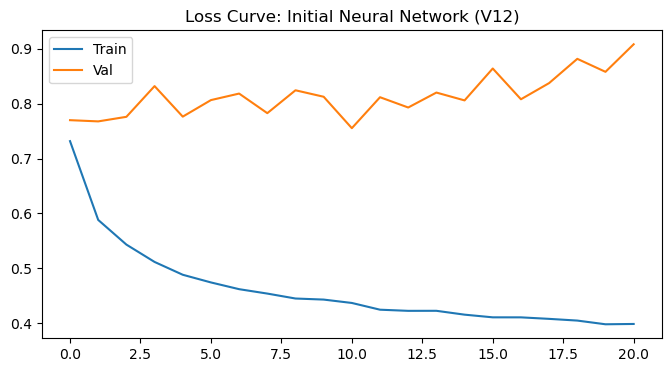

In [26]:
# Build and train initial neural network
model_v12_init = build_initial_nn(X_train_v12.shape[1])
history_v12_init = model_v12_init.fit(
    X_train_v12, y_train_v12,
    validation_data=(X_val_v12, y_val_v12),
    epochs=50, batch_size=32, callbacks=[early_stop], verbose=0
)

# Evaluate initial nn using anomEvaluator
y_pred_scaled_v12 = model_v12_init.predict(X_test_v12)
y_pred_raw_v12 = anomEvaluator.unscale_predictions(y_pred_scaled_v12, data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v12, y_pred_raw_v12, "Initial Neural Network", stage)
anomEvaluator.plot_loss(history_v12_init, "Initial Neural Network", stage)

Starting Hyperparameter Search for V12...
 1/67 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[V12 | Tuned NN] MAE: 20.44 bu/ac | RMSE: 25.26 bu/ac | R2: -0.1663
Calculating feature importance for V12 (this may take a minute)...


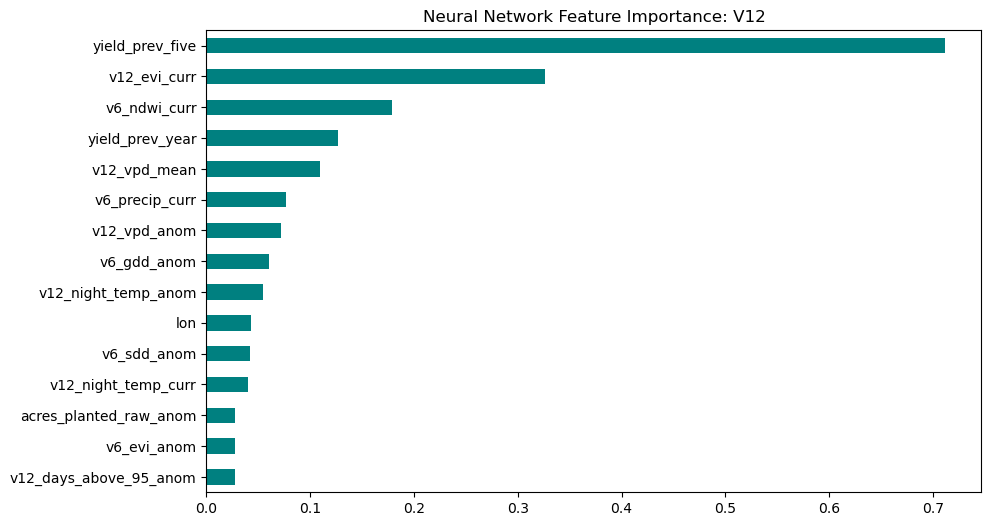

In [27]:
# initial model hyperparameter tuning
tuner_v12 = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v12.shape[1]),
    objective='val_loss', max_trials=10, executions_per_trial=1, directory='tuning_dir_anom', project_name=f'{stage}_initial'
)

print(f"Starting Hyperparameter Search for {stage}...")
tuner_v12.search(X_train_v12, y_train_v12, epochs=50, validation_data=(X_val_v12, y_val_v12), callbacks=[early_stop], verbose=0)

# get best model and evaluate
model_v12_tuned = tuner_v12.get_best_models(num_models=1)[0]
y_pred_tuned_raw_v12 = anomEvaluator.unscale_predictions(model_v12_tuned.predict(X_test_v12), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v12, y_pred_tuned_raw_v12, "Tuned NN", stage)

# feature analysis
anomEvaluator.plot_nn_importance(model_v12_tuned, X_val_v12, y_val_v12, feat_names_v12, stage)

### Engineering/Pruning

In [28]:
# feature engineering + train new neural network

# new data sets (e = engineered)
X_train_v12_e, feat_names_v12_e = add_bio_features(X_train_v12, data['feature_names'], 'v12', prev_stage='v6')
X_val_v12_e, _ = add_bio_features(X_val_v12, data['feature_names'], 'v12', prev_stage='v6')
X_test_v12_e, _ = add_bio_features(X_test_v12, data['feature_names'], 'v12', prev_stage='v6')

# train new model on data sets with engineered features + find best hyperparameters
tuner_v12_eng = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v12_e.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_engineered'
)
print(f"Tuning Engineered Model for {stage}...")
tuner_v12_eng.search(X_train_v12_e, y_train_v12, epochs=50, validation_data=(X_val_v12_e, y_val_v12), callbacks=[early_stop], verbose=0)
model_v12_eng_tuned = tuner_v12_eng.get_best_models(num_models=1)[0]

# Evaluate Engineered
y_pred_v12_eng = anomEvaluator.unscale_predictions(model_v12_eng_tuned.predict(X_test_v12_e), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v12, y_pred_v12_eng, "Tuned Engineered NN", stage)

Tuning Engineered Model for V12...
44/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[V12 | Tuned Engineered NN] MAE: 19.54 bu/ac | RMSE: 25.92 bu/ac | R2: -0.2278


{'MAE': 19.53806386729639,
 'RMSE': 25.922249398047864,
 'R2': -0.2277502539986782}

In [29]:
# prune features to get rid of useless ones and decrease noise

# find top 40 most useful features and only save them (p = pruned dataset)
top_idx_v12 = get_pruned_indices(model_v12_eng_tuned, X_val_v12_e, y_val_v12, feat_names_v12_e, top_n=40)
X_train_v12_p, X_val_v12_p, X_test_v12_p = X_train_v12_e[:, top_idx_v12], X_val_v12_e[:, top_idx_v12], X_test_v12_e[:, top_idx_v12]
feat_names_v12_p = [feat_names_v12_e[i] for i in top_idx_v12]
print(f"Top 40 Features for {stage}: {feat_names_v12_p}")

# train another model on pruned data set + find best hyperparameters
tuner_v12_pruned = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_v12_p.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_pruned'
)
print(f"Final Tuning for Pruned {stage} Model...")
tuner_v12_pruned.search(X_train_v12_p, y_train_v12, epochs=50, validation_data=(X_val_v12_p, y_val_v12), callbacks=[early_stop], verbose=0)
model_v12_pruned_tuned = tuner_v12_pruned.get_best_models(num_models=1)[0]

# Final Evaluation
y_pred_v12_pruned = anomEvaluator.unscale_predictions(model_v12_pruned_tuned.predict(X_test_v12_p), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_v12, y_pred_v12_pruned, "Tuned Pruned NN", stage)


Top 40 Features for V12: ['yield_prev_five', 'v12_vpd_anom', 'v12_stress_idx', 'v12_vpd_mean', 'v6_precip_curr', 'acres_planted_raw_anom', 'v6_ndwi_curr', 'v6_vpd_anom', 'v12_diurnal_temp_range_anom', 'v12_velocity', 'yield_prev_year', 'lat', 'v6_precip_anom', 'v6_gdd_curr', 'v6_diurnal_temp_range_anom', 'acres_planted_curr', 'v12_sdd_anom', 'v12_gdd_curr', 'v6_solar_curr', 'v6_solar_anom', 'v12_night_temp_curr', 'v12_precip_anom', 'v6_gdd_anom', 'v12_thirst', 'v12_sdd_curr', 'clay_pct', 'v6_vpd_mean', 'v12_ndwi_curr', 'organic_matter_pct', 'acres_planted_pct_anom', 'extreme_cold_nov_mar', 'v12_precip_curr', 'v12_days_above_95_anom', 'slope', 'v12_ndwi_anom', 'v12_evi_curr', 'pH_soil', 'v6_ndwi_anom', 'v6_night_temp_curr', 'awc_soil']
Final Tuning for Pruned V12 Model...


C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[V12 | Tuned Pruned NN] MAE: 17.50 bu/ac | RMSE: 23.77 bu/ac | R2: -0.0322


{'MAE': 17.50208076679693,
 'RMSE': 23.768450756442586,
 'R2': -0.032206081364645645}

### Ensemble

In [30]:
model_v12_init.save('models_anom/v12_init_nn.keras')
model_v12_tuned.save('models_anom/v12_tuned_nn.keras')
model_v12_eng_tuned.save('models_anom/v12_eng_tuned_nn.keras')
model_v12_pruned_tuned.save('models_anom/v12_pruned_tuned_nn.keras')

In [31]:
# create neural network + xgboost ensemble model

# load previous models
model_v12_init = load_model(r'models_anom/v12_init_nn.keras')

# train a high-performance XGBoost on the Engineered features
print(f"Training Final XGBoost for {stage} Ensemble...")
xgb_ensemble_v12 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_ensemble_v12.fit(X_train_v12_e, y_train_v12)

# generate ensemble prediction
# We use X_test_v12_p for the Pruned NN and X_test_v12_e for the Engineered XGBoost
y_pred_v12_ensemble_a = get_ensemble_predictions(
    model_v12_init, xgb_ensemble_v12, 
    X_test_v12, X_test_v12_e, 
    data['scaler_y'], anomEvaluator, weight_nn=0.2
)

# 3. Evaluate the Ensemble
anomEvaluator.evaluate(y_test_raw_v12, y_pred_v12_ensemble_a, "Weighted Ensemble (NN+XGB)", stage)

Training Final XGBoost for V12 Ensemble...
[V12 | Weighted Ensemble (NN+XGB)] MAE: 17.40 bu/ac | RMSE: 22.37 bu/ac | R2: 0.0858


{'MAE': 17.400755108303755,
 'RMSE': 22.36812133690239,
 'R2': 0.08583690822806833}

## R1

In [32]:
stage = 'R1'
data = stage_datasets[stage]

X_train_r1, y_train_r1 = data['X_train'], data['y_train'][:, anomEvaluator.target_idx]
X_val_r1, y_val_r1 = data['X_val'], data['y_val'][:, anomEvaluator.target_idx]
X_test_r1 = data['X_test']
y_test_raw_r1 = data['y_test_raw'][:, anomEvaluator.target_idx]
feat_names_r1 = data['feature_names']

### Initial

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[R1 | Initial Neural Network] MAE: 15.07 bu/ac | RMSE: 19.49 bu/ac | R2: 0.3061


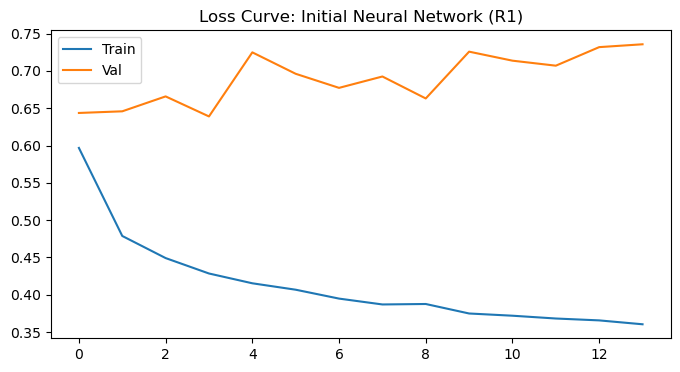

In [33]:
# Build and train initial neural network
model_r1_init = build_initial_nn(X_train_r1.shape[1])
history_r1_init = model_r1_init.fit(
    X_train_r1, y_train_r1,
    validation_data=(X_val_r1, y_val_r1),
    epochs=50, batch_size=32, callbacks=[early_stop], verbose=0
)

# Evaluate initial nn using anomEvaluator
y_pred_scaled_r1 = model_r1_init.predict(X_test_r1)
y_pred_raw_r1 = anomEvaluator.unscale_predictions(y_pred_scaled_r1, data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r1, y_pred_raw_r1, "Initial Neural Network", stage)
anomEvaluator.plot_loss(history_r1_init, "Initial Neural Network", stage)

Starting Hyperparameter Search for R1...
45/67 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[R1 | Tuned NN] MAE: 15.49 bu/ac | RMSE: 20.07 bu/ac | R2: 0.2643
Calculating feature importance for R1 (this may take a minute)...


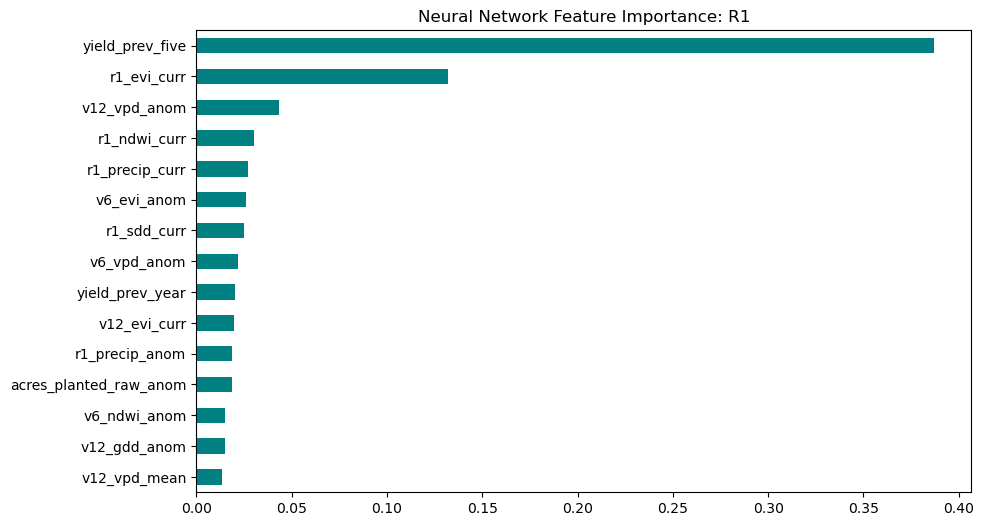

In [34]:
# initial model hyperparameter tuning
tuner_r1 = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r1.shape[1]),
    objective='val_loss', max_trials=10, executions_per_trial=1, directory='tuning_dir_anom', project_name=f'{stage}_initial'
)

print(f"Starting Hyperparameter Search for {stage}...")
tuner_r1.search(X_train_r1, y_train_r1, epochs=50, validation_data=(X_val_r1, y_val_r1), callbacks=[early_stop], verbose=0)

# get best model and evaluate
model_r1_tuned = tuner_r1.get_best_models(num_models=1)[0]
y_pred_tuned_raw_r1 = anomEvaluator.unscale_predictions(model_r1_tuned.predict(X_test_r1), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r1, y_pred_tuned_raw_r1, "Tuned NN", stage)

# feature analysis
anomEvaluator.plot_nn_importance(model_r1_tuned, X_val_r1, y_val_r1, feat_names_r1, stage)

### Engineering/Pruning

In [35]:
# feature engineering + train new neural network

# new data sets (e = engineered)
X_train_r1_e, feat_names_r1_e = add_bio_features(X_train_r1, data['feature_names'], 'r1', prev_stage='v12')
X_val_r1_e, _ = add_bio_features(X_val_r1, data['feature_names'], 'r1', prev_stage='v12')
X_test_r1_e, _ = add_bio_features(X_test_r1, data['feature_names'], 'r1', prev_stage='v12')

# train new model on data sets with engineered features + find best hyperparameters
tuner_r1_eng = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r1_e.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_engineered'
)
print(f"Tuning Engineered Model for {stage}...")
tuner_r1_eng.search(X_train_r1_e, y_train_r1, epochs=50, validation_data=(X_val_r1_e, y_val_r1), callbacks=[early_stop], verbose=0)
model_r1_eng_tuned = tuner_r1_eng.get_best_models(num_models=1)[0]

# Evaluate Engineered
y_pred_r1_eng = anomEvaluator.unscale_predictions(model_r1_eng_tuned.predict(X_test_r1_e), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r1, y_pred_r1_eng, "Tuned Engineered NN", stage)

Tuning Engineered Model for R1...
 1/67 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[R1 | Tuned Engineered NN] MAE: 15.46 bu/ac | RMSE: 20.22 bu/ac | R2: 0.2528


{'MAE': 15.46455305924177,
 'RMSE': 20.221991954384407,
 'R2': 0.25284186414890863}

In [36]:
# prune features to get rid of useless ones and decrease noise

# find top 50 most useful features and only save them (p = pruned dataset)
top_idx_r1 = get_pruned_indices(model_r1_eng_tuned, X_val_r1_e, y_val_r1, feat_names_r1_e, top_n=50)
X_train_r1_p, X_val_r1_p, X_test_r1_p = X_train_r1_e[:, top_idx_r1], X_val_r1_e[:, top_idx_r1], X_test_r1_e[:, top_idx_r1]
feat_names_r1_p = [feat_names_r1_e[i] for i in top_idx_r1]
print(f"Top 50 Features for {stage}: {feat_names_r1_p}")

# train another model on pruned data set + find best hyperparameters
tuner_r1_pruned = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r1_p.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_pruned'
)
print(f"Final Tuning for Pruned {stage} Model...")
tuner_r1_pruned.search(X_train_r1_p, y_train_r1, epochs=50, validation_data=(X_val_r1_p, y_val_r1), callbacks=[early_stop], verbose=0)
model_r1_pruned_tuned = tuner_r1_pruned.get_best_models(num_models=1)[0]

# Final Evaluation
y_pred_r1_pruned = anomEvaluator.unscale_predictions(model_r1_pruned_tuned.predict(X_test_r1_p), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r1, y_pred_r1_pruned, "Tuned Pruned NN", stage)


Top 50 Features for R1: ['r1_evi_curr', 'r1_sdd_anom', 'r1_vpd_mean', 'r1_days_above_95_anom', 'r1_ndwi_curr', 'v6_days_above_95_anom', 'acres_planted_raw_anom', 'r1_stress_idx', 'r1_precip_curr', 'v6_sdd_anom', 'r1_solar_anom', 'r1_ndwi_anom', 'r1_night_temp_curr', 'r1_velocity', 'precip_oct_april_curr', 'v6_diurnal_temp_range_curr', 'v12_vpd_mean', 'r1_night_temp_anom', 'awc_soil', 'r1_precip_anom', 'extreme_cold_nov_mar', 'v6_solar_anom', 'v12_solar_anom', 'lon', 'r1_days_above_95_curr', 'yield_prev_five', 'v6_gdd_anom', 'organic_matter_pct', 'v12_solar_curr', 'v6_solar_curr', 'abandonment_rate_prev_five', 'yield_prev_year', 'v6_ndwi_anom', 'r1_sdd_curr', 'v6_sdd_curr', 'v12_evi_anom', 'gdd_full_season_hist', 'v12_night_temp_curr', 'v6_vpd_anom', 'r1_thirst', 'r1_diurnal_temp_range_anom', 'v12_ndwi_anom', 'v6_diurnal_temp_range_anom', 'v12_gdd_curr', 'sand_pct', 'v6_ndwi_curr', 'v12_precip_curr', 'precip_oct_april_anom', 'v6_gdd_curr', 'v12_days_above_95_curr']
Final Tuning for Prun

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[R1 | Tuned Pruned NN] MAE: 14.80 bu/ac | RMSE: 19.26 bu/ac | R2: 0.3225


{'MAE': 14.803066879218903,
 'RMSE': 19.256323573562067,
 'R2': 0.32249670247628615}

### Ensemble

In [37]:
model_r1_init.save('models_anom/r1_init_nn.keras')
model_r1_tuned.save('models_anom/r1_tuned_nn.keras')
model_r1_eng_tuned.save('models_anom/r1_eng_tuned_nn.keras')
model_r1_pruned_tuned.save('models_anom/r1_pruned_tuned_nn.keras')

In [38]:
# create neural network + xgboost ensemble model

# load previous models
model_r1_eng_tuned = load_model(r'models_anom/r1_eng_tuned_nn.keras')

# train a high-performance XGBoost on the Engineered features
print(f"Training Final XGBoost for {stage} Ensemble...")
xgb_ensemble_r1 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_ensemble_r1.fit(X_train_r1_e, y_train_r1)

# generate ensemble prediction
# We use X_test_r1_p for the Pruned NN and X_test_r1_e for the Engineered XGBoost
y_pred_r1_ensemble_a = get_ensemble_predictions(
    model_r1_eng_tuned, xgb_ensemble_r1, 
    X_test_r1_e, X_test_r1_e, 
    data['scaler_y'], anomEvaluator, weight_nn=0.3
)

# Evaluate the Ensemble
anomEvaluator.evaluate(y_test_raw_r1, y_pred_r1_ensemble_a, "Weighted Ensemble (NN+XGB)", stage)

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Training Final XGBoost for R1 Ensemble...
[R1 | Weighted Ensemble (NN+XGB)] MAE: 14.65 bu/ac | RMSE: 18.84 bu/ac | R2: 0.3516


{'MAE': 14.6455376733707,
 'RMSE': 18.838069104982207,
 'R2': 0.35160831801758874}

## R3

In [39]:
stage = 'R3'
data = stage_datasets[stage]

X_train_r3, y_train_r3 = data['X_train'], data['y_train'][:, anomEvaluator.target_idx]
X_val_r3, y_val_r3 = data['X_val'], data['y_val'][:, anomEvaluator.target_idx]
X_test_r3 = data['X_test']
y_test_raw_r3 = data['y_test_raw'][:, anomEvaluator.target_idx]
feat_names_r3 = data['feature_names']

### Initial

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[R3 | Initial Neural Network] MAE: 13.92 bu/ac | RMSE: 18.33 bu/ac | R2: 0.3862


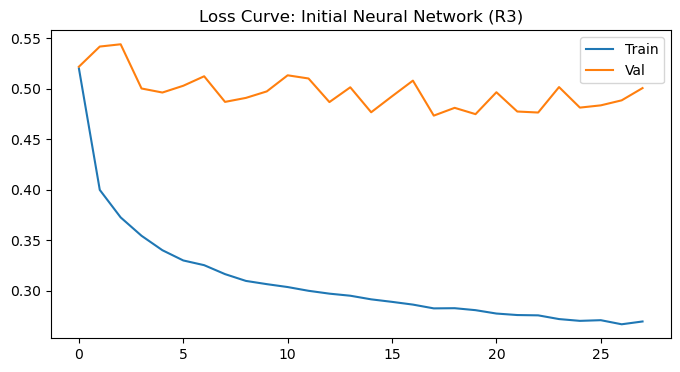

In [40]:
# Build and train initial neural network
model_r3_init = build_initial_nn(X_train_r3.shape[1])
history_r3_init = model_r3_init.fit(
    X_train_r3, y_train_r3,
    validation_data=(X_val_r3, y_val_r3),
    epochs=50, batch_size=32, callbacks=[early_stop], verbose=0
)

# Evaluate initial nn using anomEvaluator
y_pred_scaled_r3 = model_r3_init.predict(X_test_r3)
y_pred_raw_r3 = anomEvaluator.unscale_predictions(y_pred_scaled_r3, data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r3, y_pred_raw_r3, "Initial Neural Network", stage)
anomEvaluator.plot_loss(history_r3_init, "Initial Neural Network", stage)

Starting Hyperparameter Search for R3...


C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[R3 | Tuned NN] MAE: 13.91 bu/ac | RMSE: 18.32 bu/ac | R2: 0.3868
Calculating feature importance for R3 (this may take a minute)...


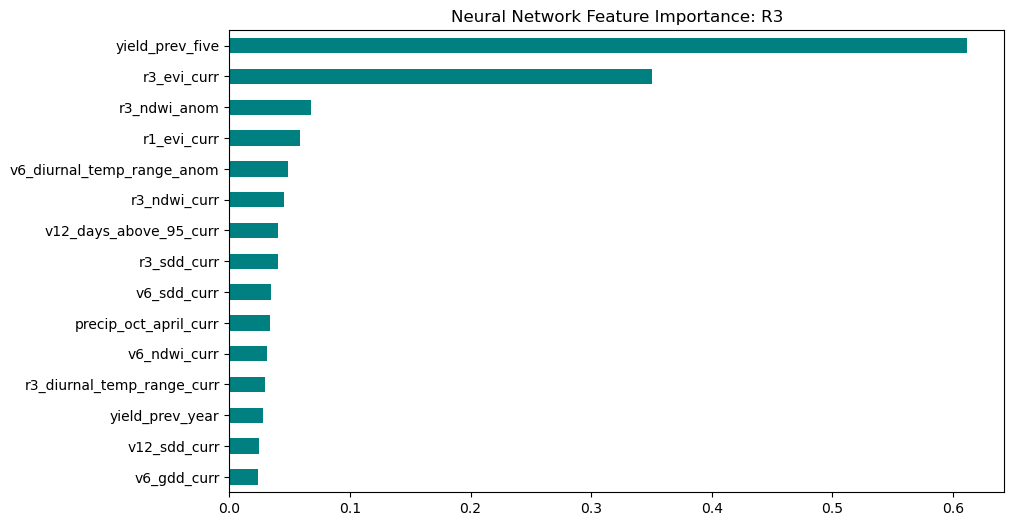

In [41]:
# initial model hyperparameter tuning
tuner_r3 = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r3.shape[1]),
    objective='val_loss', max_trials=10, executions_per_trial=1, directory='tuning_dir_anom', project_name=f'{stage}_initial'
)

print(f"Starting Hyperparameter Search for {stage}...")
tuner_r3.search(X_train_r3, y_train_r3, epochs=50, validation_data=(X_val_r3, y_val_r3), callbacks=[early_stop], verbose=0)

# get best model and evaluate
model_r3_tuned = tuner_r3.get_best_models(num_models=1)[0]
y_pred_tuned_raw_r3 = anomEvaluator.unscale_predictions(model_r3_tuned.predict(X_test_r3), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r3, y_pred_tuned_raw_r3, "Tuned NN", stage)

# feature analysis
anomEvaluator.plot_nn_importance(model_r3_tuned, X_val_r3, y_val_r3, feat_names_r3, stage)

### Engineering/Pruning

In [42]:
# feature engineering + train new neural network

# new data sets (e = engineered)
X_train_r3_e, feat_names_r3_e = add_bio_features(X_train_r3, data['feature_names'], 'r3', prev_stage='r1')
X_val_r3_e, _ = add_bio_features(X_val_r3, data['feature_names'], 'r3', prev_stage='r1')
X_test_r3_e, _ = add_bio_features(X_test_r3, data['feature_names'], 'r3', prev_stage='r1')

# train new model on data sets with engineered features + find best hyperparameters
tuner_r3_eng = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r3_e.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_engineered'
)
print(f"Tuning Engineered Model for {stage}...")
tuner_r3_eng.search(X_train_r3_e, y_train_r3, epochs=50, validation_data=(X_val_r3_e, y_val_r3), callbacks=[early_stop], verbose=0)
model_r3_eng_tuned = tuner_r3_eng.get_best_models(num_models=1)[0]

# Evaluate Engineered
y_pred_r3_eng = anomEvaluator.unscale_predictions(model_r3_eng_tuned.predict(X_test_r3_e), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r3, y_pred_r3_eng, "Tuned Engineered NN", stage)

Tuning Engineered Model for R3...
 1/67 ━━━━━━━━━━━━━━━━━━━━ 9s 146ms/step

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[R3 | Tuned Engineered NN] MAE: 14.20 bu/ac | RMSE: 18.97 bu/ac | R2: 0.3425


{'MAE': 14.203316979683162,
 'RMSE': 18.969485978584707,
 'R2': 0.34253023002319316}

In [43]:
# prune features to get rid of useless ones and decrease noise

# find top 60 most useful features and only save them (p = pruned dataset)
top_idx_r3 = get_pruned_indices(model_r3_eng_tuned, X_val_r3_e, y_val_r3, feat_names_r3_e, top_n=60)
X_train_r3_p, X_val_r3_p, X_test_r3_p = X_train_r3_e[:, top_idx_r3], X_val_r3_e[:, top_idx_r3], X_test_r3_e[:, top_idx_r3]
feat_names_r3_p = [feat_names_r3_e[i] for i in top_idx_r3]
print(f"Top 60 Features for {stage}: {feat_names_r3_p}")

# train another model on pruned data set + find best hyperparameters
tuner_r3_pruned = kt.RandomSearch(
    lambda hp: build_tunable_nn(hp, X_train_r3_p.shape[1]),
    objective='val_loss', max_trials=8, directory='tuning_dir_anom', project_name=f'{stage}_pruned'
)
print(f"Final Tuning for Pruned {stage} Model...")
tuner_r3_pruned.search(X_train_r3_p, y_train_r3, epochs=50, validation_data=(X_val_r3_p, y_val_r3), callbacks=[early_stop], verbose=0)
model_r3_pruned_tuned = tuner_r3_pruned.get_best_models(num_models=1)[0]

# Final Evaluation
y_pred_r3_pruned = anomEvaluator.unscale_predictions(model_r3_pruned_tuned.predict(X_test_r3_p), data['scaler_y'])
anomEvaluator.evaluate(y_test_raw_r3, y_pred_r3_pruned, "Tuned Pruned NN", stage)

Top 60 Features for R3: ['yield_prev_five', 'r3_evi_curr', 'r1_evi_curr', 'r3_ndwi_anom', 'r3_ndwi_curr', 'v6_evi_anom', 'extreme_cold_nov_mar', 'v6_ndwi_anom', 'v12_vpd_anom', 'r1_precip_curr', 'v12_evi_curr', 'r3_sdd_anom', 'r1_sdd_anom', 'r1_ndwi_curr', 'r3_velocity', 'r1_days_above_95_curr', 'v6_ndwi_curr', 'acres_planted_raw_anom', 'r3_stress_idx', 'lon', 'yield_prev_year', 'r3_thirst', 'r1_solar_curr', 'r1_diurnal_temp_range_curr', 'precip_oct_april_curr', 'r1_night_temp_anom', 'v6_diurnal_temp_range_anom', 'r1_precip_anom', 'v12_vpd_mean', 'v12_days_above_95_curr', 'r3_precip_anom', 'v6_days_above_95_anom', 'v12_solar_anom', 'r1_diurnal_temp_range_anom', 'r1_gdd_curr', 'r3_sdd_curr', 'v6_solar_curr', 'r1_vpd_mean', 'r3_solar_anom', 'v12_sdd_anom', 'v6_precip_curr', 'v6_gdd_curr', 'v6_sdd_anom', 'v12_sdd_curr', 'v6_sdd_curr', 'v12_ndwi_curr', 'r1_days_above_95_anom', 'v6_vpd_mean', 'acres_planted_pct_anom', 'v12_gdd_anom', 'gdd_full_season_hist', 'precip_oct_april_anom', 'abandon

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 18 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
[R3 | Tuned Pruned NN] MAE: 14.37 bu/ac | RMSE: 18.85 bu/ac | R2: 0.3508


{'MAE': 14.365902107242606,
 'RMSE': 18.850408509859687,
 'R2': 0.3507586143892979}

### Ensemble

In [44]:
model_r3_init.save('models_anom/r3_init_nn.keras')
model_r3_tuned.save('models_anom/r3_tuned_nn.keras')
model_r3_eng_tuned.save('models_anom/r3_eng_tuned_nn.keras')
model_r3_pruned_tuned.save('models_anom/r3_pruned_tuned_nn.keras')

In [45]:
# create neural network + xgboost ensemble model

# load previous models
model_r3_pruned_tuned = load_model(r'models_anom/r3_pruned_tuned_nn.keras')

# train a high-performance XGBoost on the Engineered features
print(f"Training Final XGBoost for {stage} Ensemble...")
xgb_ensemble_r3 = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
xgb_ensemble_r3.fit(X_train_r3_e, y_train_r3)

# generate ensemble prediction
# We use X_test_r3_p for the Pruned NN and X_test_r3_e for the Engineered XGBoost
y_pred_r3_ensemble_a = get_ensemble_predictions(
    model_r3_pruned_tuned, xgb_ensemble_r3, 
    X_test_r3_p, X_test_r3_e, 
    data['scaler_y'], anomEvaluator, weight_nn=0.7
)

# 3. Evaluate the Ensemble
anomEvaluator.evaluate(y_test_raw_r3, y_pred_r3_ensemble_a, "Weighted Ensemble (NN+XGB)", stage)

C:\Users\praka\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 18 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Training Final XGBoost for R3 Ensemble...
[R3 | Weighted Ensemble (NN+XGB)] MAE: 14.04 bu/ac | RMSE: 18.49 bu/ac | R2: 0.3753


{'MAE': 14.036693221356645,
 'RMSE': 18.49003462764212,
 'R2': 0.3753451557146563}

# See Results

## Print Results

In [46]:
def print_results_summary(dict):    
        # Flatten the nested dictionary
        rows = []
        for stage, models in dict.items():
            for model_name, metrics in models.items():
                row = {'Stage': stage, 'Model': model_name}
                row.update(metrics)
                rows.append(row)
        
        df = pd.DataFrame(rows)
        
        # Reorder columns for readability
        cols = ['Stage', 'Model', 'MAE', 'RMSE', 'R2']
        df = df[cols].sort_values(by=['Stage', 'R2'], ascending=[True, False])
        
        print("\n" + "="*50)
        print("      CORN YIELD ANOMALY PERFORMANCE SUMMARY")
        print("="*50)
        display(df.style.background_gradient(subset=['R2'], cmap='RdYlGn'))
        return df

In [47]:
print_results_summary(anomEvaluator.all_results)


      CORN YIELD ANOMALY PERFORMANCE SUMMARY


,Stage,Model,MAE,RMSE,R2
29,R1,Weighted Ensemble (NN+XGB),14.645538,18.838069,0.351608
24,R1,XGBoost,14.867232,19.062497,0.336067
28,R1,Tuned Pruned NN,14.803067,19.256324,0.322497
23,R1,Random Forest,15.031561,19.404701,0.312016
25,R1,Initial Neural Network,15.072301,19.487497,0.306132
26,R1,Tuned NN,15.490878,20.066684,0.264274
27,R1,Tuned Engineered NN,15.464553,20.221992,0.252842
22,R1,Linear Regression,16.329141,21.127423,0.184437
21,R1,5-Year Avg Yield,156.232146,161.334442,-46.557481
20,R1,Prev Year Yield,157.607570,164.225550,-48.277210


,Stage,Model,MAE,RMSE,R2
29,R1,Weighted Ensemble (NN+XGB),14.645538,18.838069,0.351608
24,R1,XGBoost,14.867232,19.062497,0.336067
28,R1,Tuned Pruned NN,14.803067,19.256324,0.322497
23,R1,Random Forest,15.031561,19.404701,0.312016
25,R1,Initial Neural Network,15.072301,19.487497,0.306132
26,R1,Tuned NN,15.490878,20.066684,0.264274
27,R1,Tuned Engineered NN,15.464553,20.221992,0.252842
22,R1,Linear Regression,16.329141,21.127423,0.184437
21,R1,5-Year Avg Yield,156.232146,161.334442,-46.557481
20,R1,Prev Year Yield,157.607570,164.225550,-48.277210


In [48]:
anom_summary = save_results_to_csv(anomEvaluator, filename='anom_model_results.csv')
display(anom_summary)

✅ Results successfully saved to anom_model_results.csv


,Stage,Model,MAE,RMSE,R2
0,V6,Prev Year Yield,157.607570,164.225550,-48.277210
1,V6,5-Year Avg Yield,156.232146,161.334442,-46.557481
2,V6,Linear Regression,18.305678,25.284643,-0.168095
3,V6,Random Forest,17.872842,23.088462,0.026010
4,V6,XGBoost,17.544091,22.967021,0.036229
5,V6,Initial Neural Network,17.519936,23.537762,-0.012267
6,V6,Tuned NN,17.202632,23.853161,-0.039577
7,V6,Tuned Engineered NN,16.838311,23.372454,0.001902
8,V6,Tuned Pruned NN,19.996282,26.863719,-0.318551
9,V6,Weighted Ensemble (NN+XGB),17.005511,22.828830,0.047792


## Visualizations

### Stage wise feature importance

In [50]:
def get_ensemble_bio_importance(stage, goal='anom'):
    """
    Calculates biological importance for the Ensemble by permuting 
    features and observing the drop in Ensemble MAE.
    """
    s = stage.lower()
    data = stage_datasets[stage.upper()]
    evaluator = anomEvaluator
    
    # 1. Identify models and their specific datasets
    # Mapping based on your specific 'best' configurations
    if s == 'v6':
        nn_model, X_nn = globals()[f'model_v6_tuned'], data['X_test']
    elif s == 'v12':
        nn_model, X_nn = globals()[f'model_v12_init'], data['X_test']
    elif s == 'r1':
        nn_model, X_nn = globals()[f'model_r1_eng_tuned'], globals()[f'X_test_r1_e']
    elif s == 'r3':
        nn_model, X_nn = globals()[f'model_r3_pruned_tuned'], globals()[f'X_test_r3_p']
        
    xgb_model = globals()[f'xgb_ensemble_{s}']
    X_xgb = globals()[f'X_test_{s}_e']
    y_true_raw = data['y_test_raw'][:, evaluator.target_idx]
    
    # Baseline Prediction
    y_pred_base = get_ensemble_predictions(nn_model, xgb_model, X_nn, X_xgb, data['scaler_y'], evaluator)
    baseline_mae = mean_absolute_error(y_true_raw, y_pred_base)
    
    # Biological Feature Groups
    # We aggregate based on the Engineered feature names (the most comprehensive set)
    feat_names_e = globals()[f'feat_names_{s}_e']
    evi_indices = [i for i, name in enumerate(feat_names_e) if 'evi' in name.lower()]
    ndwi_indices = [i for i, name in enumerate(feat_names_e) if 'ndwi' in name.lower()]
    
    results = {'EVI': 0, 'NDWI': 0}
    
    # Permutation Logic
    for label, indices in [('EVI', evi_indices), ('NDWI', ndwi_indices)]:
        X_xgb_permuted = X_xgb.copy()
        # Shuffle all features in this biological group
        for idx in indices:
            np.random.shuffle(X_xgb_permuted[:, idx])
        
        # Note: For simplicity, we permute the XGB input (Engineered) 
        # which contains almost all info. This is a highly accurate proxy for ensemble sensitivity.
        y_pred_permuted = get_ensemble_predictions(nn_model, xgb_model, X_nn, X_xgb_permuted, data['scaler_y'], evaluator)
        permuted_mae = mean_absolute_error(y_true_raw, y_pred_permuted)
        
        # Importance = Increase in Error
        results[label] = max(0, permuted_mae - baseline_mae)
        
    return results

In [51]:
def plot_feature_importance_shift(stage_list, importance_data, goal_suffix):
    """
    stage_list: ['V6', 'V12', 'R1', 'R3']
    importance_data: Dict mapping stage to { 'EVI': score, 'NDWI': score }
    """
    plt.figure(figsize=(10, 6))
    
    evi_scores = [importance_data[s]['EVI'] for s in stage_list]
    ndwi_scores = [importance_data[s]['NDWI'] for s in stage_list]
    
    plt.plot(stage_list, evi_scores, 'go-', linewidth=3, label='EVI (Biomass/Greenness)', markersize=10)
    plt.plot(stage_list, ndwi_scores, 'bo-', linewidth=3, label='NDWI (Water Content)', markersize=10)
    
    plt.title(f"Shift in Biological Predictors: {goal_suffix.upper()} Yield", fontsize=15)
    plt.ylabel("Relative Importance (Permutation)", fontsize=12)
    plt.xlabel("Corn Growth Stage", fontsize=12)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.savefig(f"feature_shift_{goal_suffix}.png", dpi=300)
    plt.show()

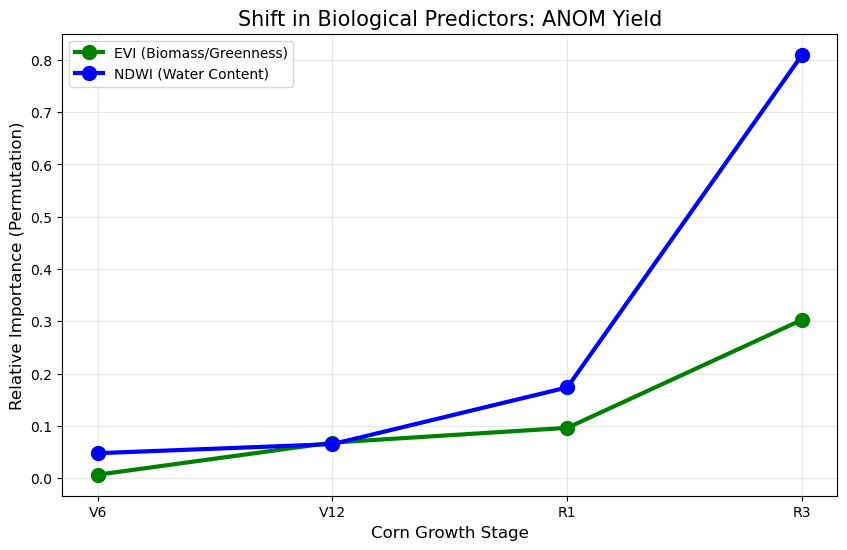

In [52]:
# --- To Generate the Shift Graph ---
bio_data = {s: get_ensemble_bio_importance(s) for s in ['V6', 'V12', 'R1', 'R3']}
plot_feature_importance_shift(['V6', 'V12', 'R1', 'R3'], bio_data, 'anom')